# Instant Policy - PoC
The aim of this notebook is to perform a "simple" proof of concept for the Instant Policy approach. The model will be trained with multiple simple planar trajectories and then evaluated against other simples and complex trajectories.

In [1]:
from src.classes.trajectory_generator import TrajectoryGenerator
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def perturb_params(params: dict, noise_scale: float = 0.15) -> dict:
    """Perturba levemente los parámetros para generar una demo semánticamente consistente."""
    perturbed = {}
    for key, value in params.items():
        if isinstance(value, bool):
            perturbed[key] = value
        elif isinstance(value, int):
            # Integers (e.g. frequency ratios): discrete ±1 step, minimum 1
            perturbed[key] = value + np.random.choice([-1, 0, 1])
            perturbed[key] = max(1, perturbed[key])
        elif isinstance(value, float):
            # Additive perturbation with a floor so near-zero values still get perturbed
            scale = max(abs(value), 1.0)
            perturbed[key] = value + np.random.uniform(-noise_scale, noise_scale) * scale
        elif isinstance(value, tuple):
            perturbed[key] = tuple(
                v + np.random.uniform(-noise_scale, noise_scale) * max(abs(v), 1.0)
                for v in value
            )
        else:
            perturbed[key] = value

    return perturbed
    
def create_demo_pair(generator_fn, params: dict, n_points: int):
    """
    Crea el par (context, target) para In-Context Imitation Learning.
    
    - target:  trayectoria "objetivo" generada con los params originales
    - context: trayectoria semánticamente similar pero geométricamente distinta,
               generada con params levemente perturbados (es la "demo experta")
    """
    target  = generator_fn(n_points=n_points, **params).astype(np.float32)
    context = generator_fn(n_points=n_points, **perturb_params(params)).astype(np.float32)
    return context, target

In [3]:
def get_trajectory_types(n_points):
    """Devuelve la lista de generadores aleatorios parametrizados"""
    return [
        ("linear", TrajectoryGenerator.linear, dict( 
            start=(np.random.uniform(-1, 1), np.random.uniform(-1, 1)), 
            angle=np.random.uniform(0, 360), 
            length=np.random.uniform(0.5, 2.0)
        )),
        ("sinusoidal", TrajectoryGenerator.sinusoidal, dict( 
            amp=np.random.uniform(0.1, 1.0), 
            freq=np.random.uniform(0.5, 3.0), 
            phase=np.random.uniform(0, 2 * np.pi)
        )),
        ("parabolic", TrajectoryGenerator.parabolic, dict( 
            a=np.random.uniform(-2.0, 2.0), 
            h=np.random.uniform(-1.0, 1.0), 
            k=np.random.uniform(-1.0, 1.0)
        )),
        ("sigmoid", TrajectoryGenerator.sigmoid, dict( 
            L=np.random.uniform(0.5, 2.0), 
            k=np.random.uniform(5, 15), 
            x0=np.random.uniform(0.5, 1.5)
        )),
        # Para la PoC se mantendrán solo curvas abiertas, continuas y con rangos acotados por simplicidad.
        # ("circular", TrajectoryGenerator.circular, dict( 
        #     radius=np.random.uniform(0.5, 2.0), 
        #     arc_ratio=np.random.uniform(0.5, 1.0), 
        #     start_angle=np.random.uniform(0, 360)
        # )),
        # ("exponential", TrajectoryGenerator.exponential, dict( 
        #     a=np.random.uniform(0.5, 2.0), 
        #     b=np.random.uniform(-1.5, 1.5)
        # )),
        # ("staggered_step", TrajectoryGenerator.staggered_step, dict(
        #     n_steps=np.random.randint(2, 6), 
        #     step_height=np.random.uniform(0.2, 1.0)
        # )),
        # ("spiral", TrajectoryGenerator.spiral, dict( 
        #     b=np.random.uniform(0.05, 0.2), 
        #     theta_max=np.random.uniform(2 * np.pi, 6 * np.pi)
        # )),
        # ("lemniscate", TrajectoryGenerator.lemniscate, dict(
        #     a=np.random.uniform(1.0, 2.5))),
        # ("lissajous", TrajectoryGenerator.lissajous, dict(
        #     A=np.random.uniform(0.5, 2.0), 
        #     B=np.random.uniform(0.5, 2.0), 
        #     a=np.random.randint(1, 5), 
        #     b=np.random.randint(1, 5), 
        #     delta=np.random.uniform(0, np.pi)
        # ))
    ]

In [4]:
def orchestrator(file_name, n_per_type=100, n_points=100):
    """Orquestador principal para generar y guardar el dataset."""
    
    with h5py.File(file_name, 'w') as f:
        data_group = f.create_group("data")
        demo_idx = 0
        
        for _ in range(n_per_type):
            for name, fn, params in get_trajectory_types(n_points):
                ctx, tgt = create_demo_pair(fn, params, n_points)
                
                demo_grp = data_group.create_group(f"demo_{demo_idx}")
                demo_grp.create_dataset("context", data=ctx)
                demo_grp.create_dataset("target",  data=tgt)
                
                # Metadatos para facilitar el filtrado posterior
                demo_grp.attrs["type"]        = name
                demo_grp.attrs["num_samples"] = n_points
                
                demo_idx += 1
        
        # Atributo global del dataset
        f.attrs["total_demos"] = demo_idx

    print(f"\nDataset guardado en '{file_name}' con {demo_idx} demostraciones totales.")


In [5]:
FILENAME = "dataset_instant_policy_2d.h5"
N_EXAMPLES = 1000
N_POINTS   = 200
orchestrator(FILENAME, n_per_type=N_EXAMPLES, n_points=N_POINTS)


Dataset guardado en 'dataset_instant_policy_2d.h5' con 4000 demostraciones totales.


C:\Users\gabriel.quiroga\AppData\Local\Temp\ipykernel_40328\2859700421.py:4: DeprecationWarning: This function is deprecated. Please call randint(0, 4000 + 1) instead
  d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)


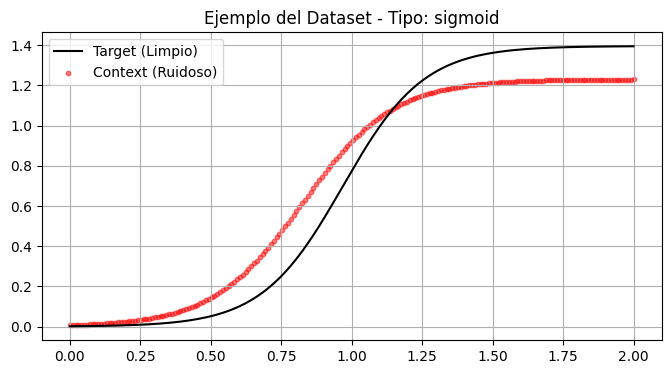

In [13]:
# Prueba rápida de visualización
with h5py.File(FILENAME, 'r') as f:
    n = f.attrs['total_demos']
    d = f[f'data/demo_{np.random.random_integers(0, n)}'] # Una demo aleatoria (probablemente sinusoidal)
    plt.figure(figsize=(8,4))
    plt.plot(d['target'][:,0], d['target'][:,1], 'k-', label='Target (Limpio)')
    plt.scatter(d['context'][:,0], d['context'][:,1], c='r', alpha=0.5, s=10, label='Context (Ruidoso)')
    plt.title(f"Ejemplo del Dataset - Tipo: {d.attrs['type']}")
    plt.legend()
    plt.grid(True)
    plt.show()